In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
import atproto as bsk
import networkx as nx
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#from senha import senha

In [2]:
#pip install atproto
#Login: tpmars2@gmail.com

In [2]:
client = bsk.Client()
client.login('tpmars.bsky.social', 'ViniVini@123')

ProfileViewDetailed(did='did:plc:ccvg46rdila3t6zlietwi6qe', handle='tpmars.bsky.social', associated=ProfileAssociated(chat=None, feedgens=0, labeler=False, lists=0, starter_packs=0, py_type='app.bsky.actor.defs#profileAssociated', activitySubscription={'allowSubscriptions': 'followers'}), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:ccvg46rdila3t6zlietwi6qe/bafkreidsdfe4gtx2ayfomg3xjdxbugo3dsejdgsm2qrpti25mqbyrnmyhu@jpeg', banner=None, created_at='2025-07-10T18:22:57.932Z', description=None, display_name='', followers_count=1, follows_count=3, indexed_at='2025-07-10T18:22:57.932Z', joined_via_starter_pack=None, labels=[], pinned_post=None, posts_count=1, verification=None, viewer=ViewerState(blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by_list=None, py_type='app.bsky.actor.defs#viewerState'), py_type='app.bsky.actor.defs#profileViewDetailed')

In [3]:
def pega_nomes_usuarios_por_post(termo: str):

    search = client.app.bsky.feed.search_posts({'q': termo})
    nomes_usuarios = [el.author['handle'] for el in dict(search)['posts']]

    return nomes_usuarios

def pega_comentarios_usuarios_por_post(termo: str):

    search = client.app.bsky.feed.search_posts({'q': termo})
    comentarios = [el.record.text for el in dict(search)['posts']]

    return comentarios

In [4]:
#retorna um dicionario com o usuario e seus seguidores
def pega_seguidores(nome_usuario: str) -> dict:
    
    #pega o tipo que contem com os seguidores
    resposta = client.get_followers(nome_usuario)

    #separa apenas o nome
    seguidores = []
    for el in dict(resposta)['followers']: 
        seguidores.append(el['handle'])
    
    return {'usuario': nome_usuario, 'seguidores': seguidores}

In [5]:

#recebe uma lista de nomes de usuarios e retorna uma lista com dicionarios da funcao anterior
def pega_seguidores_lista(lista_nomes: list): 
    
    lista_usuarios_seguidores = []
    for usuario in lista_nomes: 
        lista_usuarios_seguidores.append(pega_seguidores(usuario))

    return lista_usuarios_seguidores

In [6]:
nomes_usuarios          = pega_nomes_usuarios_por_post('Igreja Gaza')
dicionario_seguidores   = pega_seguidores_lista(nomes_usuarios)


In [13]:
grafo = nx.DiGraph()

In [15]:
for el in dicionario_seguidores: 
    for seguidor in el['seguidores']:
        grafo.add_edge(u_of_edge= el['usuario'], v_of_edge=seguidor)
        #print(el['usuario'], seguidore)

In [21]:
print(grafo.number_of_edges())

707


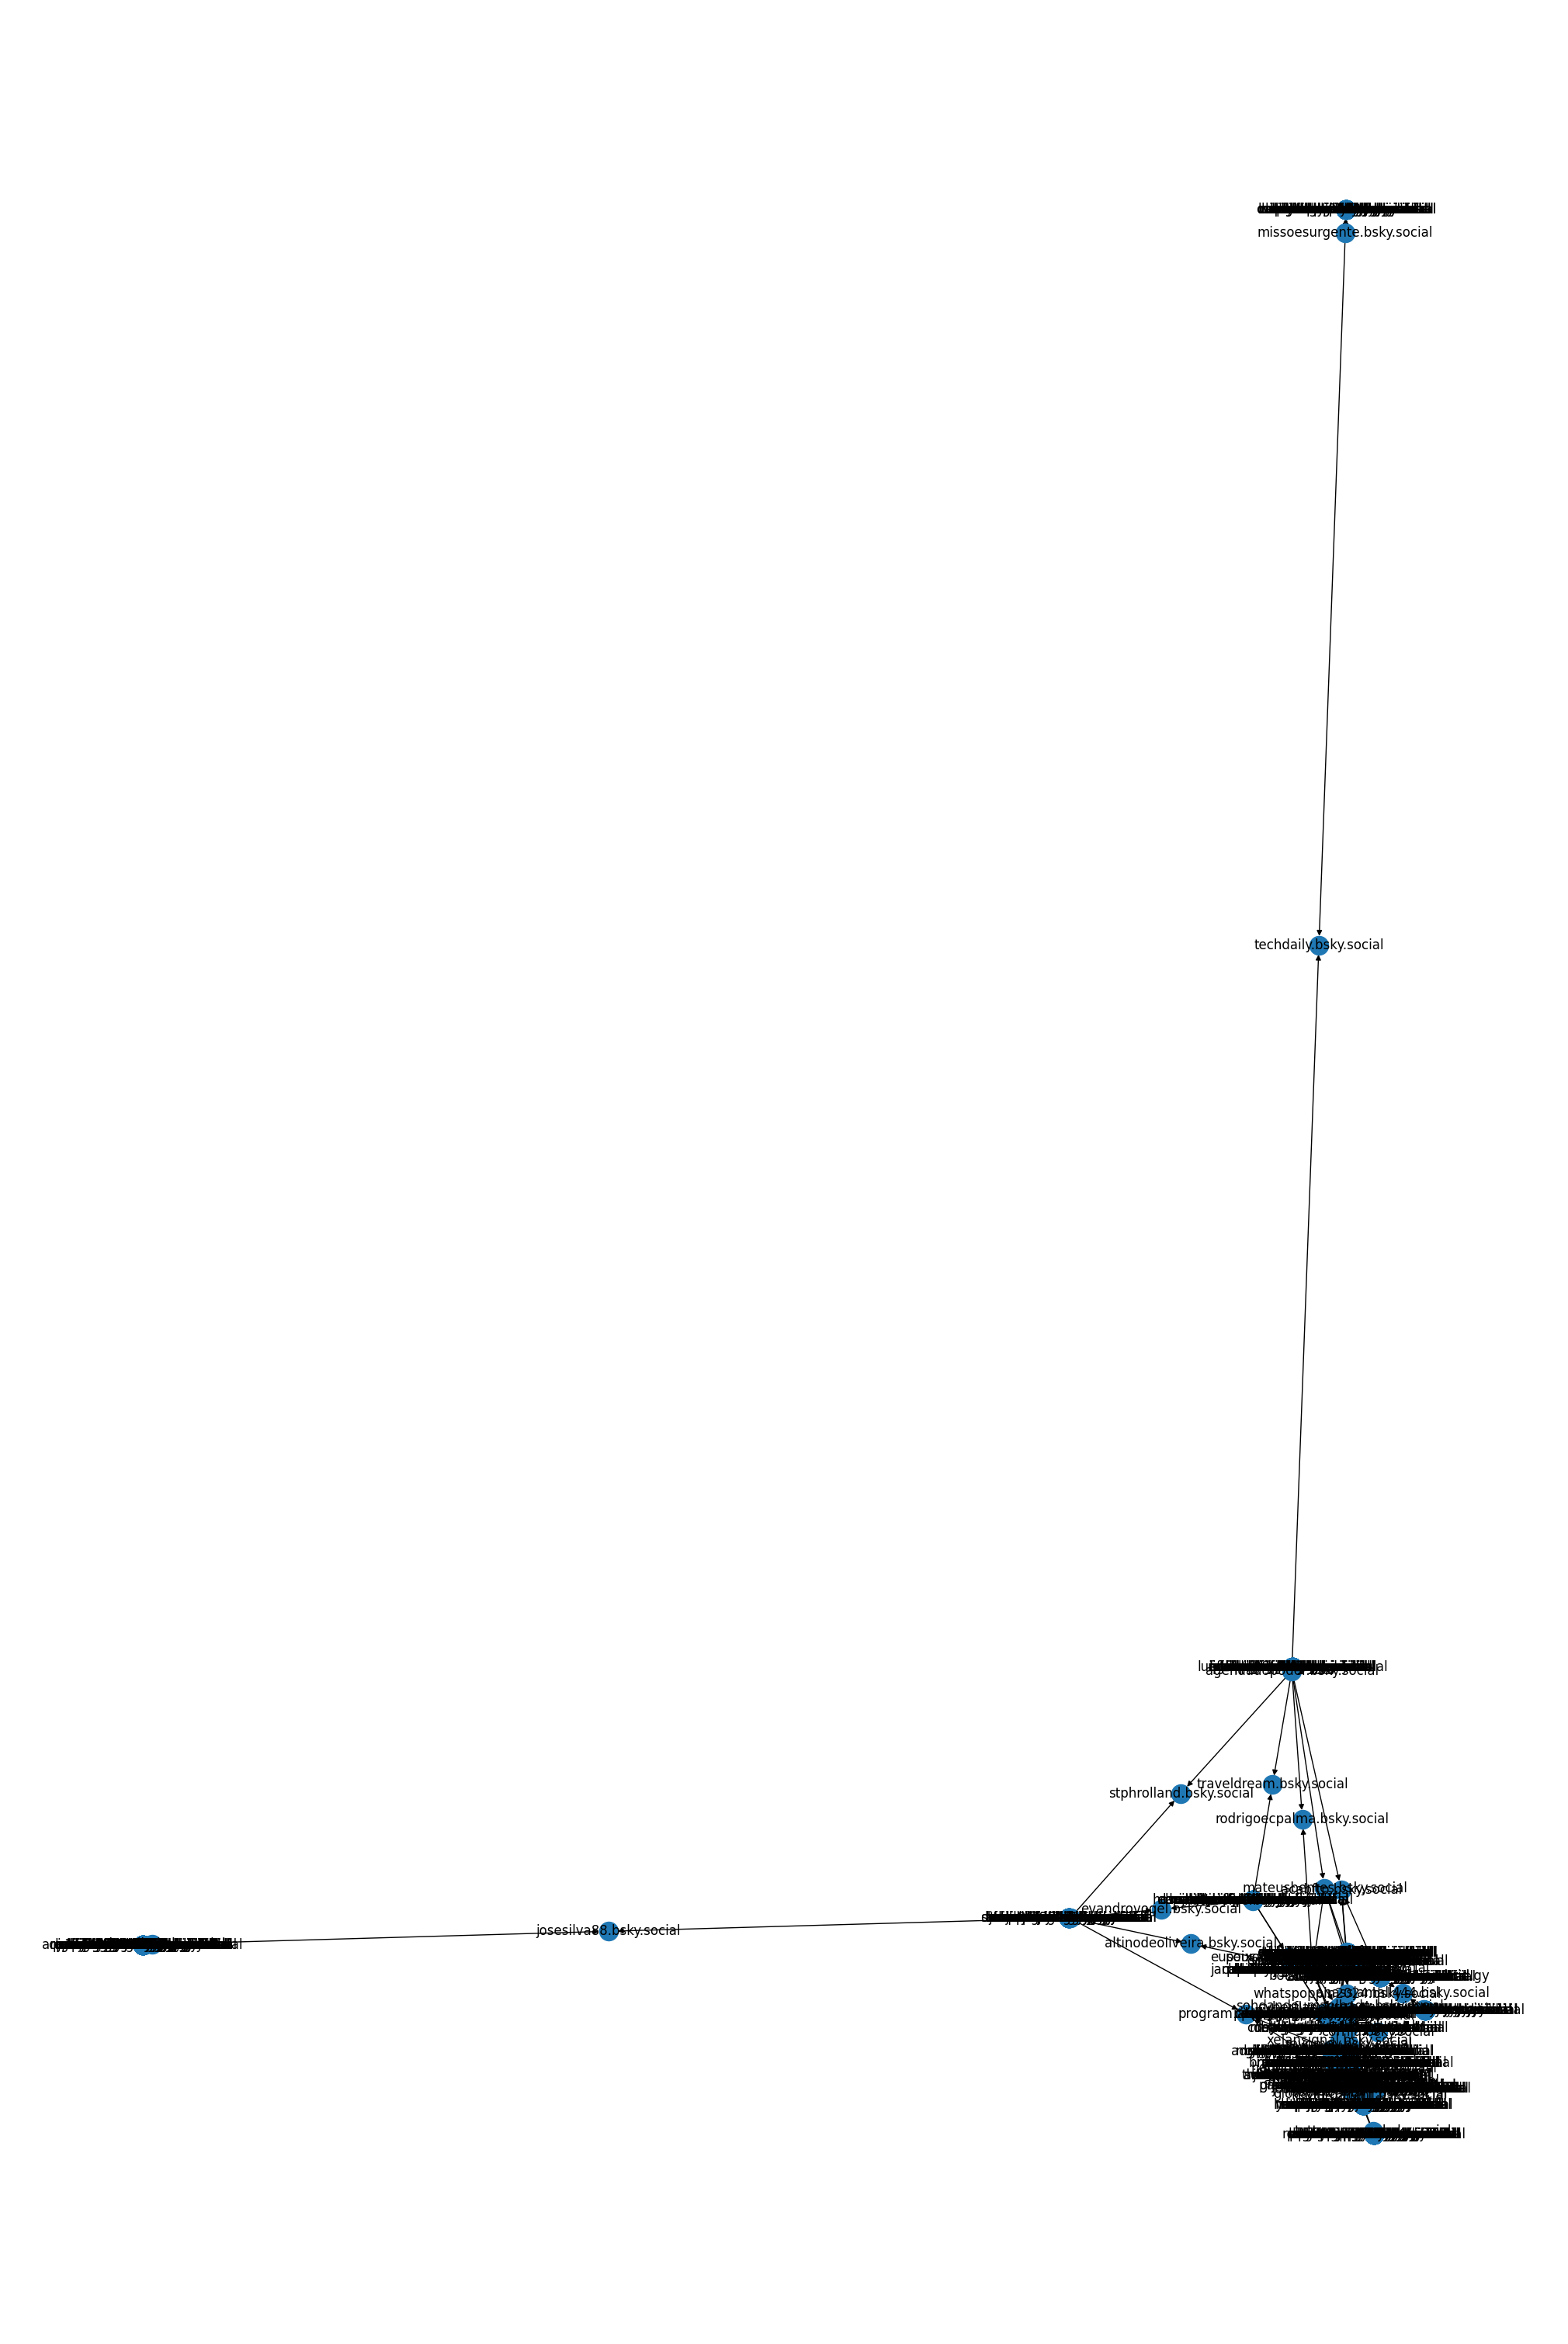

In [24]:
plt.figure(figsize=(20, 30))
pos = nx.spectral_layout(grafo)

nx.draw(grafo, pos, with_labels = True)

In [32]:
nx.write_gml(grafo, 'grafo.gml')